# 06 – Feature Selection: BMA & LASSO

**Pipeline stage:** Feature Selection → LASSO → Advanced Modeling

Notebook này thực hiện **chọn biến (feature selection)** cho mô hình gravity di cư:

| Phương pháp | Mục tiêu | Output |
|-------------|---------|--------|
| **BMA** (Bayesian Model Averaging) | Đo xác suất quan trọng của từng biến | PIP – Posterior Inclusion Probability |
| **LASSO** (Least Absolute Shrinkage) | Chọn biến tự động qua penalized regression | Tập biến tối ưu + α* |

**Kết quả từ notebook 04–05:**
- Hausman test → FEM nhất quán hơn REM
- PPML-2 Extended: Pseudo R² ≈ 0.83, N = 14,950
- → Dùng kết quả BMA & LASSO để **xác nhận/tinh chỉnh bộ biến** cho PPML chính

> **Lưu ý:** BMA và LASSO được chạy trên **log-linear OLS** (dạng chuẩn hóa)
> vì LASSO yêu cầu target liên tục. Kết quả sau đó áp dụng lại cho PPML.

## 0. Import thư viện

In [1]:
import os, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import combinations
from scipy import stats

import statsmodels.api as sm
from sklearn.linear_model import (
    LassoCV, Lasso, RidgeCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/tables',  exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
plt.rcParams.update({'figure.dpi':120,'font.size':11})
SEED = 42
np.random.seed(SEED)
print('✅ Import OK')

✅ Import OK


## 1. Load dữ liệu & áp dụng fix lỗi (nhất quán với nb 04–05)

In [2]:
df_raw = pd.read_csv('../data/processed/migration_data_processed_2000_2022.csv', low_memory=False)

def apply_fixes(df):
    d = df.copy()
    d = d[d['migration'] > 0].copy()
    d = d[d['year'].between(2000, 2022)].copy()
    d['ln_migration'] = np.log(d['migration'])
    for col in ['ln_co2_org','ln_pm25_org','ln_bandwidth_org']:
        if col in d.columns:
            d.loc[d[col] < -20, col] = np.nan
            d.loc[d[col] == 0,  col] = np.nan
    d.loc[d['ln_internet_use_org'] == 0, 'ln_internet_use_org'] = np.nan
    return d

df = apply_fixes(df_raw)
print(f'Shape sau fix: {df.shape}')
print(f'Pairs: {df["pair_id"].nunique()} | Years: {df["year"].nunique()} ({df["year"].min()}–{df["year"].max()})')

Shape sau fix: (8360, 80)
Pairs: 364 | Years: 23 (2000–2022)


## 2. Xác định tập biến ứng viên

Chia thành 2 nhóm:
- **Nhóm A – Biến gốc**: 13 biến log-transformed, không có missing nhiều
- **Nhóm B – Biến PCA**: PC1–PC6 (đã bao hàm toàn bộ variation của tập biến gốc)

In [3]:
# ── Nhóm A: Biến gốc (không NaN quá nhiều) ──────────────────────────────
GROUP_A = [
    'ln_gdppc_org',    # GDPpc nước gốc        – push factor kinh tế
    'ln_gdppc_des',    # GDPpc nước đến        – pull factor kinh tế
    'ln_pop_org',      # Dân số nước gốc       – pool di cư
    'ln_pop_des',      # Dân số nước đến       – sức chứa
    'ln_dist',         # Khoảng cách           – chi phí di cư
    'comlang_off',     # Ngôn ngữ chung        – rào cản văn hóa
    'contig',          # Biên giới chung       – thuận tiện
    'colony',          # Lịch sử thuộc địa    – mạng lưới
    'inflation_org',   # Lạm phát nước gốc    – bất ổn kinh tế
    'inflation_des',   # Lạm phát nước đến    – môi trường đầu tư
    'ln_co2_org',      # CO2 nước gốc         – chất lượng MT
    'ln_disaster_org', # Thiên tai nước gốc   – push môi trường
    'ln_disaster_des', # Thiên tai nước đến   – pull/push đến
]

# ── Nhóm B: PCA scores ───────────────────────────────────────────────────
GROUP_B = ['PC1','PC2','PC3','PC4','PC5','PC6']

# ── Nhóm C: Tất cả (kể cả biến có NaN nhiều hơn) ────────────────────────
GROUP_C = GROUP_A + ['ln_internet_use_org','ln_bandwidth_org']

DEP_VAR = 'ln_migration'

# Kiểm tra missing
print('=== Số missing trong GROUP_A ===')
miss = df[GROUP_A+[DEP_VAR]].isnull().sum()
print(miss[miss>0] if miss.sum()>0 else '  Không có missing')
print(f'  N đầy đủ (GROUP_A): {df[GROUP_A+[DEP_VAR]].dropna().shape[0]:,}')
print()
print('=== Số missing trong GROUP_C ===')
miss_c = df[GROUP_C+[DEP_VAR]].isnull().sum()
print(miss_c[miss_c>0])
print(f'  N đầy đủ (GROUP_C): {df[GROUP_C+[DEP_VAR]].dropna().shape[0]:,}')

=== Số missing trong GROUP_A ===
  Không có missing
  N đầy đủ (GROUP_A): 8,360

=== Số missing trong GROUP_C ===
ln_internet_use_org      52
ln_bandwidth_org       1301
dtype: int64
  N đầy đủ (GROUP_C): 7,059


## 3. Bayesian Model Averaging (BMA)

### Phương pháp
BMA liệt kê **tất cả 2^k mô hình** con có thể từ k biến ứng viên, tính **BIC weight**
cho mỗi mô hình, rồi tính **Posterior Inclusion Probability (PIP)** của từng biến:

$$\text{PIP}(x_j) = \sum_{M: x_j \in M} P(M | \text{data})$$

$$P(M | \text{data}) \propto \exp\left(-\frac{1}{2}\text{BIC}_M\right)$$

| PIP | Diễn giải |
|-----|-----------|
| ≥ 0.95 | Bằng chứng rất mạnh → giữ biến |
| 0.75–0.95 | Bằng chứng mạnh |
| 0.50–0.75 | Bằng chứng trung bình |
| < 0.50 | Bằng chứng yếu → có thể loại |

In [4]:
# ── BMA: liệt kê 2^13 = 8192 mô hình ──────────────────────────────────
d_bma = df[GROUP_A + [DEP_VAR]].dropna().copy()
y_bma = d_bma[DEP_VAR].values
n_bma = len(y_bma)
k_bma = len(GROUP_A)

print(f'BMA: N={n_bma:,} | k={k_bma} biến | Tổng mô hình = 2^{k_bma} = {2**k_bma:,}')
print('Đang chạy... (có thể mất 30–60 giây)')
t0 = time.time()

bma_records = []
for r in range(1, k_bma + 1):
    for combo in combinations(range(k_bma), r):
        cols = [GROUP_A[i] for i in combo]
        X_sub = sm.add_constant(d_bma[cols].values)
        try:
            res = sm.OLS(y_bma, X_sub).fit()
            bma_records.append({
                'vars'   : cols,
                'k'      : r,
                'bic'    : res.bic,
                'aic'    : res.aic,
                'rsq'    : res.rsquared,
                'rsq_adj': res.rsquared_adj,
            })
        except Exception:
            pass

print(f'Hoàn thành {len(bma_records):,} mô hình trong {time.time()-t0:.1f}s')

# ── Tính BIC weights ──────────────────────────────────────────────────────
bma_df = pd.DataFrame(bma_records)
bma_df['delta_bic']  = bma_df['bic'] - bma_df['bic'].min()
bma_df['bic_weight'] = np.exp(-0.5 * bma_df['delta_bic'])
bma_df['bic_weight'] /= bma_df['bic_weight'].sum()  # normalize

# ── Posterior Inclusion Probability (PIP) ─────────────────────────────────
pip_dict = {}
for v in GROUP_A:
    mask = bma_df['vars'].apply(lambda x: v in x)
    pip_dict[v] = float(bma_df.loc[mask, 'bic_weight'].sum())

pip_series = pd.Series(pip_dict).sort_values(ascending=False)

print('\n=== Posterior Inclusion Probability (PIP) ===')
print(f"{'Biến':<30s} {'PIP':>8s} {'Mức bằng chứng':<20s}")
print('-'*62)
for v, p in pip_series.items():
    if   p >= 0.95: level = '★★★ Rất mạnh'
    elif p >= 0.75: level = '★★  Mạnh'
    elif p >= 0.50: level = '★   Trung bình'
    else:           level = '    Yếu'
    print(f'{v:<30s} {p:>8.4f} {level}')

BMA: N=8,360 | k=13 biến | Tổng mô hình = 2^13 = 8,192
Đang chạy... (có thể mất 30–60 giây)
Hoàn thành 8,191 mô hình trong 18.4s

=== Posterior Inclusion Probability (PIP) ===
Biến                                PIP Mức bằng chứng      
--------------------------------------------------------------
ln_gdppc_org                     1.0000 ★★★ Rất mạnh
ln_gdppc_des                     1.0000 ★★★ Rất mạnh
ln_pop_org                       1.0000 ★★★ Rất mạnh
ln_pop_des                       1.0000 ★★★ Rất mạnh
ln_dist                          1.0000 ★★★ Rất mạnh
comlang_off                      1.0000 ★★★ Rất mạnh
contig                           1.0000 ★★★ Rất mạnh
colony                           1.0000 ★★★ Rất mạnh
ln_co2_org                       1.0000 ★★★ Rất mạnh
ln_disaster_des                  1.0000 ★★★ Rất mạnh
ln_disaster_org                  0.0438     Yếu
inflation_org                    0.0306     Yếu
inflation_des                    0.0116     Yếu


In [5]:
# ── Top 10 mô hình theo BIC ──────────────────────────────────────────────
top_models = bma_df.nsmallest(10, 'bic')[['vars','k','bic','rsq','bic_weight']].copy()
top_models['bic_weight_pct'] = (top_models['bic_weight'] * 100).round(3)
print('=== Top 10 mô hình theo BIC weight ===')
for i, (_, row) in enumerate(top_models.iterrows()):
    print(f'  #{i+1:2d} | BIC={row["bic"]:,.1f} | R²={row["rsq"]:.4f}'
          f' | Weight={row["bic_weight_pct"]:.3f}%')
    print(f'      Vars ({row["k"]}): {row["vars"]}')

=== Top 10 mô hình theo BIC weight ===
  # 1 | BIC=30,444.2 | R²=0.5224 | Weight=91.652%
      Vars (10): ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'ln_dist', 'comlang_off', 'contig', 'colony', 'ln_co2_org', 'ln_disaster_des']
  # 2 | BIC=30,450.4 | R²=0.5225 | Weight=4.172%
      Vars (11): ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'ln_dist', 'comlang_off', 'contig', 'colony', 'ln_co2_org', 'ln_disaster_org', 'ln_disaster_des']
  # 3 | BIC=30,451.1 | R²=0.5225 | Weight=2.857%
      Vars (11): ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'ln_dist', 'comlang_off', 'contig', 'colony', 'inflation_org', 'ln_co2_org', 'ln_disaster_des']
  # 4 | BIC=30,453.1 | R²=0.5224 | Weight=1.069%
      Vars (11): ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'ln_dist', 'comlang_off', 'contig', 'colony', 'inflation_des', 'ln_co2_org', 'ln_disaster_des']
  # 5 | BIC=30,456.9 | R²=0.5227 | Weight=0.156%
      Vars (12): ['ln_gdppc_org', 

### 3.1 Visualize BMA – PIP Chart

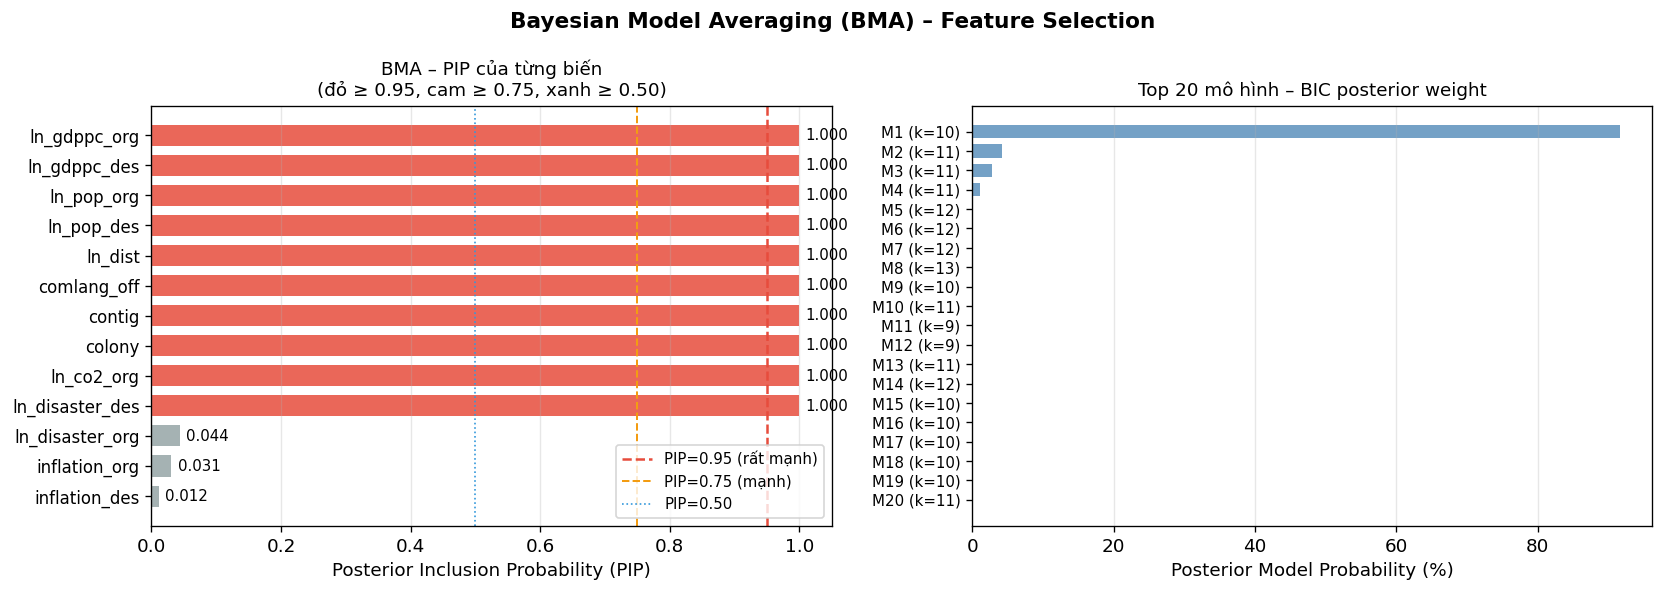

✅ Saved: output/figures/bma_pip_chart.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: PIP bar chart ──────────────────────────────────────────────────
ax = axes[0]
colors_pip = ['#e74c3c' if p>=0.95 else ('#f39c12' if p>=0.75 else
              ('#3498db' if p>=0.50 else '#95a5a6'))
              for p in pip_series.values]

bars = ax.barh(range(len(pip_series)), pip_series.values,
               color=colors_pip, alpha=0.85, height=0.7)
ax.axvline(0.95, color='#e74c3c', linestyle='--', lw=1.5, label='PIP=0.95 (rất mạnh)')
ax.axvline(0.75, color='#f39c12', linestyle='--', lw=1.2, label='PIP=0.75 (mạnh)')
ax.axvline(0.50, color='#3498db', linestyle=':',  lw=1.0, label='PIP=0.50')

ax.set_yticks(range(len(pip_series)))
ax.set_yticklabels(pip_series.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Posterior Inclusion Probability (PIP)', fontsize=11)
ax.set_title('BMA – PIP của từng biến\n(đỏ ≥ 0.95, cam ≥ 0.75, xanh ≥ 0.50)', fontsize=11)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, pip_series.values):
    ax.text(min(val+0.01, 1.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

# ── Plot 2: Top-20 model posterior probabilities ──────────────────────────
ax2 = axes[1]
top20 = bma_df.nsmallest(20, 'bic')
ax2.barh(range(len(top20)), top20['bic_weight'].values * 100,
         color='steelblue', alpha=0.75, height=0.7)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels([f'M{i+1} (k={row["k"]})'
                      for i, (_, row) in enumerate(top20.iterrows())], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Posterior Model Probability (%)', fontsize=11)
ax2.set_title('Top 20 mô hình – BIC posterior weight', fontsize=11)
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Bayesian Model Averaging (BMA) – Feature Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/bma_pip_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/bma_pip_chart.png')

### 3.2 Model Inclusion Matrix (Top 20 mô hình)

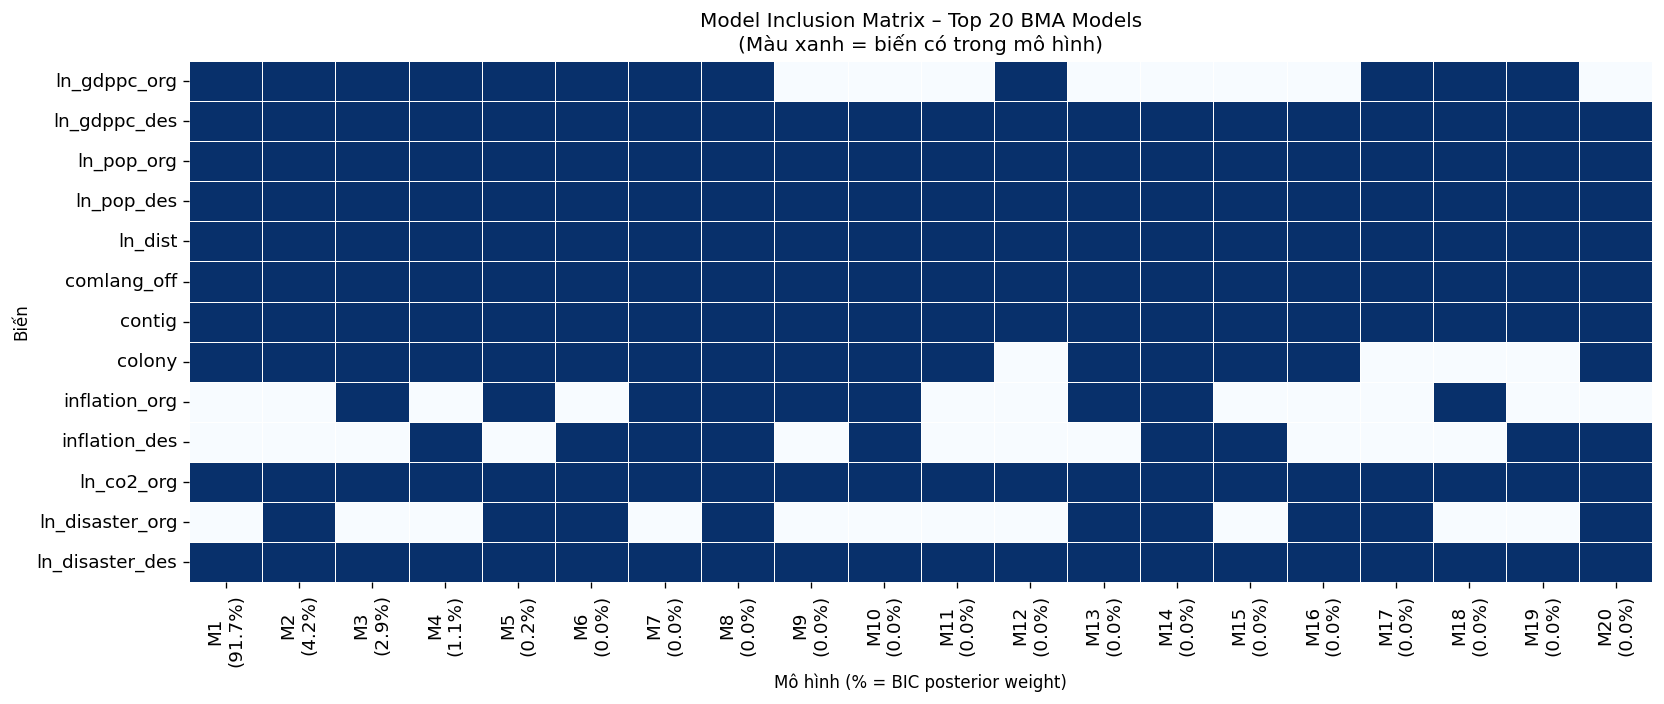

✅ Saved: output/figures/bma_inclusion_matrix.png


In [7]:
top20 = bma_df.nsmallest(20, 'bic').reset_index(drop=True)

# Build inclusion matrix
incl = np.zeros((len(GROUP_A), 20))
for j, (_, row) in enumerate(top20.iterrows()):
    for i, v in enumerate(GROUP_A):
        if v in row['vars']:
            incl[i, j] = 1

incl_df = pd.DataFrame(incl,
    index=GROUP_A,
    columns=[f'M{i+1}\n({w*100:.1f}%)' for i, w in enumerate(top20['bic_weight'])])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(incl_df, cmap='Blues', cbar=False, linewidths=0.5,
            linecolor='white', ax=ax, annot=False,
            xticklabels=True, yticklabels=True)
ax.set_title('Model Inclusion Matrix – Top 20 BMA Models\n(Màu xanh = biến có trong mô hình)', fontsize=12)
ax.set_xlabel('Mô hình (% = BIC posterior weight)', fontsize=10)
ax.set_ylabel('Biến', fontsize=10)
plt.tight_layout()
plt.savefig('../output/figures/bma_inclusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/bma_inclusion_matrix.png')

## 4. LASSO – Least Absolute Shrinkage and Selection Operator

### Phương pháp
LASSO tối thiểu hóa:

$$\min_{\beta} \left\{ \frac{1}{n}\|y - X\beta\|_2^2 + \alpha \|\beta\|_1 \right\}$$

- `α` (penalty) nhỏ → giữ nhiều biến; `α` lớn → loại bỏ nhiều biến
- **`α*` tối ưu** chọn qua **10-fold Cross Validation** (minimize MSE)
- Biến bị **shrink về 0** → loại khỏi mô hình

**Lưu ý:** Cần StandardScaler trước (LASSO nhạy với scale biến).

In [8]:
# ── Chuẩn bị dữ liệu ──────────────────────────────────────────────────────
d_lasso = df[GROUP_A + [DEP_VAR]].dropna().copy()
X_raw   = d_lasso[GROUP_A].values
y_ls    = d_lasso[DEP_VAR].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'LASSO dataset: N={len(y_ls):,} | k={len(GROUP_A)} biến')
print(f'Sau StandardScaler: mean≈{X_scaled.mean():.6f}, std≈{X_scaled.std():.6f}')

LASSO dataset: N=8,360 | k=13 biến
Sau StandardScaler: mean≈-0.000000, std≈1.000000


In [9]:
# ── LASSO Cross-Validation (10-fold) ──────────────────────────────────────
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

lasso_cv = LassoCV(
    alphas=100,           # 100 giá trị alpha thử nghiệm
    cv=kf,
    max_iter=10000,
    random_state=SEED,
    n_jobs=-1
)
lasso_cv.fit(X_scaled, y_ls)

alpha_opt = lasso_cv.alpha_
r2_lasso  = lasso_cv.score(X_scaled, y_ls)

print(f'Alpha tối ưu (α*) = {alpha_opt:.6f}')
print(f'R² (in-sample)    = {r2_lasso:.4f}')
print()

# ── Hệ số LASSO ──────────────────────────────────────────────────────────
lasso_coefs = pd.DataFrame({
    'variable'  : GROUP_A,
    'coef_std'  : lasso_cv.coef_,      # hệ số trên thang chuẩn hóa
    'selected'  : np.abs(lasso_cv.coef_) > 1e-8,
})
# Đổi về thang gốc
lasso_coefs['coef_raw'] = lasso_cv.coef_ / scaler.scale_
lasso_coefs.sort_values('coef_std', key=abs, ascending=False, inplace=True)

print(f"{'Biến':<30s} {'Coef (std)':>12s} {'Coef (raw)':>12s} {'Trạng thái':<12s}")
print('-'*70)
for _, row in lasso_coefs.iterrows():
    status = 'SELECTED ✓' if row['selected'] else 'ZEROED   ✗'
    print(f"{row['variable']:<30s} {row['coef_std']:>12.6f} {row['coef_raw']:>12.6f} {status}")

Alpha tối ưu (α*) = 0.000690
R² (in-sample)    = 0.5227

Biến                             Coef (std)   Coef (raw) Trạng thái  
----------------------------------------------------------------------
ln_gdppc_des                       0.976698     1.199770 SELECTED ✓
ln_pop_des                         0.778127     0.507661 SELECTED ✓
ln_pop_org                         0.731632     0.473923 SELECTED ✓
contig                             0.411699     1.405036 SELECTED ✓
comlang_off                        0.394708     1.413163 SELECTED ✓
ln_dist                           -0.385260    -0.338633 SELECTED ✓
ln_co2_org                         0.373093     0.343406 SELECTED ✓
ln_disaster_des                    0.371242     0.391657 SELECTED ✓
ln_gdppc_org                      -0.331700    -0.330098 SELECTED ✓
colony                             0.174920     1.069391 SELECTED ✓
ln_disaster_org                    0.053421     0.052890 SELECTED ✓
inflation_org                      0.030195     0.0100

### 4.1 Regularization Path (LASSO)

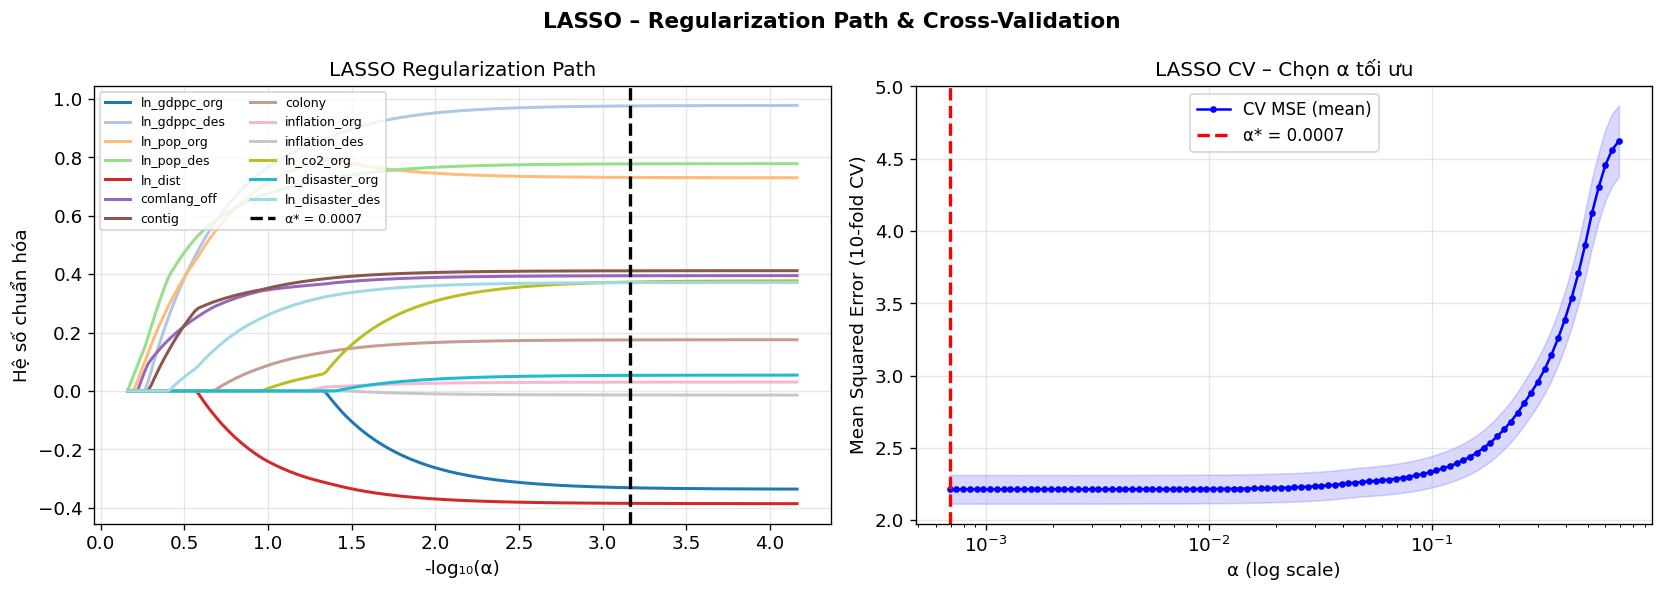

✅ Saved: output/figures/lasso_path_cv.png


In [10]:
# ── LASSO path ──────────────────────────────────────────────────────────
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_scaled, y_ls, eps=1e-4, n_alphas=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regularization path
ax = axes[0]
colors_path = plt.cm.tab20(np.linspace(0, 1, len(GROUP_A)))
for i, (var, color) in enumerate(zip(GROUP_A, colors_path)):
    ax.plot(-np.log10(alphas_path), coefs_path[i], color=color,
            linewidth=1.8, label=var)
ax.axvline(-np.log10(alpha_opt), color='black', linestyle='--',
           linewidth=2, label=f'α* = {alpha_opt:.4f}')
ax.set_xlabel('-log₁₀(α)', fontsize=11)
ax.set_ylabel('Hệ số chuẩn hóa', fontsize=11)
ax.set_title('LASSO Regularization Path', fontsize=12)
ax.legend(fontsize=7.5, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: CV MSE vs alpha
ax2 = axes[1]
alphas_cv = lasso_cv.alphas_
mse_cv    = lasso_cv.mse_path_.mean(axis=1)
mse_std   = lasso_cv.mse_path_.std(axis=1)

ax2.semilogx(alphas_cv, mse_cv, 'b-o', markersize=3, linewidth=1.5, label='CV MSE (mean)')
ax2.fill_between(alphas_cv, mse_cv-mse_std, mse_cv+mse_std, alpha=0.15, color='blue')
ax2.axvline(alpha_opt, color='red', linestyle='--', linewidth=2,
            label=f'α* = {alpha_opt:.4f}')
ax2.set_xlabel('α (log scale)', fontsize=11)
ax2.set_ylabel('Mean Squared Error (10-fold CV)', fontsize=11)
ax2.set_title('LASSO CV – Chọn α tối ưu', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('LASSO – Regularization Path & Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/lasso_path_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/lasso_path_cv.png')

### 4.2 Coefficient Chart – LASSO

Biến ĐƯỢC CHỌN (13): ['ln_gdppc_des', 'ln_pop_des', 'ln_pop_org', 'contig', 'comlang_off', 'ln_dist', 'ln_co2_org', 'ln_disaster_des', 'ln_gdppc_org', 'colony', 'ln_disaster_org', 'inflation_org', 'inflation_des']
Biến BỊ LOẠI  (0): []


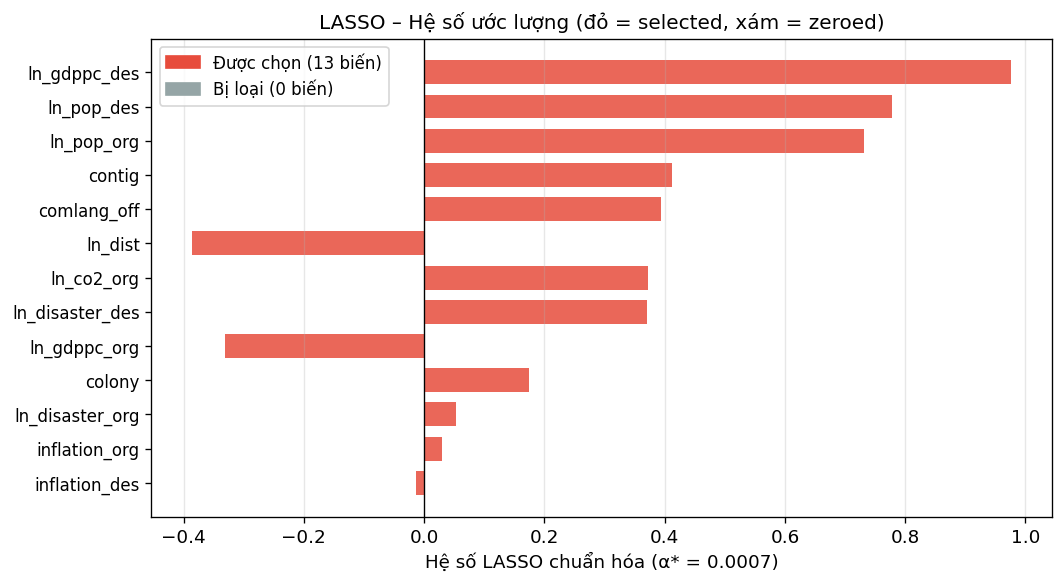

✅ Saved: output/figures/lasso_coef_chart.png


In [11]:
selected_vars   = lasso_coefs[lasso_coefs['selected']]['variable'].tolist()
eliminated_vars = lasso_coefs[~lasso_coefs['selected']]['variable'].tolist()

print(f'Biến ĐƯỢC CHỌN ({len(selected_vars)}): {selected_vars}')
print(f'Biến BỊ LOẠI  ({len(eliminated_vars)}): {eliminated_vars}')

fig, ax = plt.subplots(figsize=(9, 5))
lasso_plot = lasso_coefs.sort_values('coef_std', key=abs, ascending=True)
colors_bar = ['#e74c3c' if sel else '#95a5a6' for sel in lasso_plot['selected']]

bars = ax.barh(range(len(lasso_plot)), lasso_plot['coef_std'],
               color=colors_bar, alpha=0.85, height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_yticks(range(len(lasso_plot)))
ax.set_yticklabels(lasso_plot['variable'], fontsize=10)
ax.set_xlabel(f'Hệ số LASSO chuẩn hóa (α* = {alpha_opt:.4f})', fontsize=11)
ax.set_title('LASSO – Hệ số ước lượng (đỏ = selected, xám = zeroed)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label=f'Được chọn ({len(selected_vars)} biến)'),
    Patch(color='#95a5a6', label=f'Bị loại ({len(eliminated_vars)} biến)'),
], fontsize=10)
plt.tight_layout()
plt.savefig('../output/figures/lasso_coef_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/lasso_coef_chart.png')

## 5. LASSO trên PCA Scores

Áp dụng LASSO trên PC1–PC6 để xác định PC nào quan trọng nhất.
Kết hợp với diễn giải kinh tế từ notebook 03.

In [12]:
d_pca = df[GROUP_B + [DEP_VAR]].dropna().copy()
X_pca = StandardScaler().fit_transform(d_pca[GROUP_B].values)
y_pca = d_pca[DEP_VAR].values

lasso_pca_cv = LassoCV(alphas=100, cv=kf, max_iter=10000, random_state=SEED, n_jobs=-1)
lasso_pca_cv.fit(X_pca, y_pca)

pca_coef_df = pd.DataFrame({
    'PC'       : GROUP_B,
    'coef_std' : lasso_pca_cv.coef_,
    'selected' : np.abs(lasso_pca_cv.coef_) > 1e-8,
})

print(f'LASSO PCA – α* = {lasso_pca_cv.alpha_:.6f} | R² = {lasso_pca_cv.score(X_pca,y_pca):.4f}')
print()
print(pca_coef_df.to_string(index=False))

LASSO PCA – α* = 0.000864 | R² = 0.4395

 PC  coef_std  selected
PC1    0.1925      True
PC2    0.7635      True
PC3    0.4354      True
PC4    0.0376      True
PC5    0.6975      True
PC6    0.8318      True


## 7. Tổng hợp kết quả BMA & LASSO

So sánh quyết định chọn biến của 2 phương pháp: BMA và LASSO.

In [13]:
# ── Bảng tổng hợp BMA & LASSO ───────────────────────────────────────────
summary = pd.DataFrame({'variable': GROUP_A})

# BMA PIP
summary['PIP']  = summary['variable'].map(pip_dict).round(4)
summary['BMA']  = summary['PIP'].apply(
    lambda p: '★★★' if p>=0.95 else ('★★' if p>=0.75 else ('★' if p>=0.50 else '–'))
)

# LASSO
lasso_sel_set = set(selected_vars)
summary['LASSO']      = summary['variable'].apply(lambda v: '✓' if v in lasso_sel_set else '✗')
summary['LASSO_coef'] = summary['variable'].map(
    lasso_coefs.set_index('variable')['coef_std']
).round(4)

# Đồng thuận: tính trên 2 phương pháp (BMA PIP≥0.75 + LASSO)
summary['score_bma']   = (summary['PIP'] >= 0.75).astype(int)
summary['score_lasso'] = (summary['LASSO'] == '✓').astype(int)
summary['Đồng thuận'] = summary['score_bma'] + summary['score_lasso']

# Quyết định: GIỮ nếu cả 2 đồng ý (score=2), XEM XÉT nếu 1, LOẠI nếu 0
summary['Quyết định'] = summary['Đồng thuận'].apply(
    lambda x: '✅ GIỮ' if x == 2 else ('⚠️ XEM XÉT' if x == 1 else '❌ LOẠI')
)

summary_sorted = summary.sort_values('PIP', ascending=False)
print('=== BẢNG TỔNG HỢP FEATURE SELECTION (BMA + LASSO) ===')
print(summary_sorted[['variable','PIP','BMA','LASSO','LASSO_coef','Đồng thuận','Quyết định']].to_string(index=False))


=== BẢNG TỔNG HỢP FEATURE SELECTION (BMA + LASSO) ===
       variable    PIP BMA LASSO  LASSO_coef  Đồng thuận Quyết định
   ln_gdppc_org 1.0000 ★★★     ✓     -0.3317           2      ✅ GIỮ
   ln_gdppc_des 1.0000 ★★★     ✓      0.9767           2      ✅ GIỮ
     ln_pop_org 1.0000 ★★★     ✓      0.7316           2      ✅ GIỮ
     ln_pop_des 1.0000 ★★★     ✓      0.7781           2      ✅ GIỮ
        ln_dist 1.0000 ★★★     ✓     -0.3853           2      ✅ GIỮ
    comlang_off 1.0000 ★★★     ✓      0.3947           2      ✅ GIỮ
         contig 1.0000 ★★★     ✓      0.4117           2      ✅ GIỮ
         colony 1.0000 ★★★     ✓      0.1749           2      ✅ GIỮ
     ln_co2_org 1.0000 ★★★     ✓      0.3731           2      ✅ GIỮ
ln_disaster_des 1.0000 ★★★     ✓      0.3712           2      ✅ GIỮ
ln_disaster_org 0.0438   –     ✓      0.0534           1 ⚠️ XEM XÉT
  inflation_org 0.0306   –     ✓      0.0302           1 ⚠️ XEM XÉT
  inflation_des 0.0116   –     ✓     -0.0139           1 ⚠️ XE

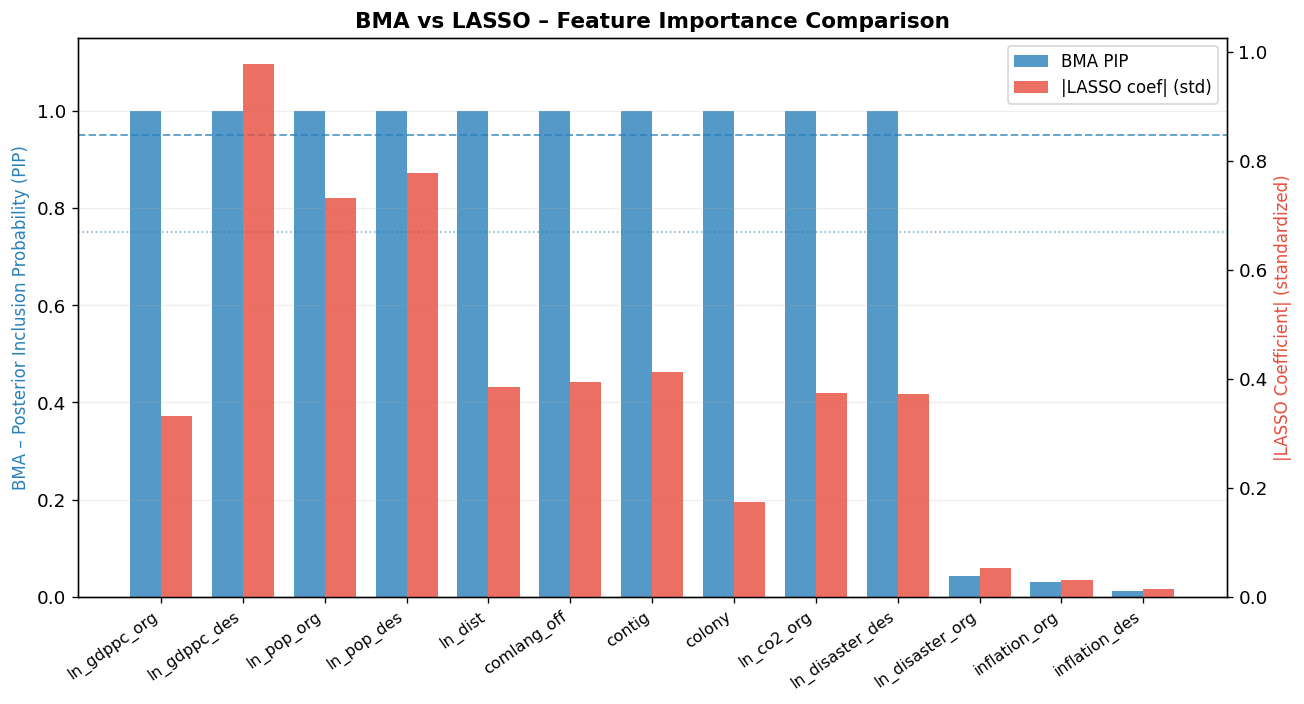

✅ Saved: output/figures/bma_vs_lasso_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

vars_sorted = summary_sorted['variable'].tolist()
pip_vals    = summary_sorted['PIP'].values
lasso_abs   = summary_sorted['variable'].map(
    lasso_coefs.set_index('variable')['coef_std'].abs()).values

x = np.arange(len(vars_sorted))
width = 0.38

ax2_twin = ax.twinx()

b1 = ax.bar(x - width/2, pip_vals, width, color='#2980b9', alpha=0.8, label='BMA PIP')
b2 = ax2_twin.bar(x + width/2, lasso_abs, width, color='#e74c3c', alpha=0.8, label='|LASSO coef| (std)')

ax.axhline(0.95, color='#2980b9', linestyle='--', lw=1.2, alpha=0.7)
ax.axhline(0.75, color='#2980b9', linestyle=':', lw=1.0, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(vars_sorted, rotation=35, ha='right', fontsize=9.5)
ax.set_ylabel('BMA – Posterior Inclusion Probability (PIP)', color='#2980b9', fontsize=10)
ax.set_ylim(0, 1.15)
ax2_twin.set_ylabel('|LASSO Coefficient| (standardized)', color='#e74c3c', fontsize=10)
ax.set_title('BMA vs LASSO – Feature Importance Comparison', fontsize=13, fontweight='bold')

lines = [b1, b2]
ax.legend(lines, [l.get_label() for l in lines], fontsize=10, loc='upper right')
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../output/figures/bma_vs_lasso_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/bma_vs_lasso_comparison.png')

## 8. OLS với biến được BMA & LASSO chọn

Chạy OLS với **bộ biến được đồng thuận** để xác nhận hệ số có ý nghĩa.

In [15]:
# Biến được CẢ HAI BMA (PIP≥0.75) VÀ LASSO đồng thuận chọn
# → đây là bộ biến thực sự được lọc, khác với OLS Full (13 biến)
FINAL_SELECTED = summary_sorted[
    summary_sorted['Đồng thuận'] == 2          # Phải đạt cả BMA lẫn LASSO
]['variable'].tolist()

print(f'OLS Full sẽ dùng: {len(GROUP_A)} biến (tất cả GROUP_A)')
print(f'OLS Selected dùng: {len(FINAL_SELECTED)} biến (BMA PIP≥0.75 + LASSO chọn)')
print(f'Biến bị loại khỏi FINAL_SELECTED: {[v for v in GROUP_A if v not in FINAL_SELECTED]}')
print()
print(f'Bộ biến cuối cùng được chọn ({len(FINAL_SELECTED)}):')
for v in FINAL_SELECTED:
    row = summary_sorted[summary_sorted['variable']==v].iloc[0]
    print(f'  {v:<30s} PIP={row["PIP"]:.4f} | LASSO={row["LASSO"]}')


OLS Full sẽ dùng: 13 biến (tất cả GROUP_A)
OLS Selected dùng: 10 biến (BMA PIP≥0.75 + LASSO chọn)
Biến bị loại khỏi FINAL_SELECTED: ['inflation_org', 'inflation_des', 'ln_disaster_org']

Bộ biến cuối cùng được chọn (10):
  ln_gdppc_org                   PIP=1.0000 | LASSO=✓
  ln_gdppc_des                   PIP=1.0000 | LASSO=✓
  ln_pop_org                     PIP=1.0000 | LASSO=✓
  ln_pop_des                     PIP=1.0000 | LASSO=✓
  ln_dist                        PIP=1.0000 | LASSO=✓
  comlang_off                    PIP=1.0000 | LASSO=✓
  contig                         PIP=1.0000 | LASSO=✓
  colony                         PIP=1.0000 | LASSO=✓
  ln_co2_org                     PIP=1.0000 | LASSO=✓
  ln_disaster_des                PIP=1.0000 | LASSO=✓


In [16]:
# =========================
# OLS FINAL (FIXED)
# =========================
d_final = df[FINAL_SELECTED + [DEP_VAR]].dropna()

# 🔥 giữ DataFrame (không dùng .values)
X_final = sm.add_constant(d_final[FINAL_SELECTED])
y_final = d_final[DEP_VAR]

ols_final = sm.OLS(y_final, X_final).fit(cov_type='HC3')

# =========================
# BUILD RESULT TABLE (SAFE)
# =========================
result_df = pd.DataFrame({
    'variable': ols_final.params.index,
    'coef'    : ols_final.params.values,
    'se'      : ols_final.bse.values,
    't_stat'  : ols_final.tvalues.values,
    'p_value' : ols_final.pvalues.values,
    'ci_lo'   : ols_final.conf_int().iloc[:,0].values,
    'ci_hi'   : ols_final.conf_int().iloc[:,1].values,
})

result_df['stars'] = result_df['p_value'].apply(
    lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
)

# =========================
# OUTPUT
# =========================
print('=== OLS với biến được chọn bởi BMA & LASSO ===')
print(f'N = {int(ols_final.nobs):,} | R² = {ols_final.rsquared:.4f} | Adj R² = {ols_final.rsquared_adj:.4f}')
print()
print(result_df[['variable','coef','se','t_stat','p_value','stars']].to_string(index=False))

=== OLS với biến được chọn bởi BMA & LASSO ===
N = 8,360 | R² = 0.5224 | Adj R² = 0.5218

       variable     coef     se   t_stat  p_value stars
          const -15.7485 0.6060 -25.9897   0.0000   ***
   ln_gdppc_org  -0.3485 0.0355  -9.8265   0.0000   ***
   ln_gdppc_des   1.2069 0.0270  44.7751   0.0000   ***
     ln_pop_org   0.4997 0.0122  40.8777   0.0000   ***
     ln_pop_des   0.5114 0.0207  24.7298   0.0000   ***
        ln_dist  -0.3358 0.0169 -19.8238   0.0000   ***
    comlang_off   1.4234 0.0579  24.5931   0.0000   ***
         contig   1.4115 0.0720  19.5926   0.0000   ***
         colony   1.0750 0.0712  15.0984   0.0000   ***
     ln_co2_org   0.3545 0.0339  10.4568   0.0000   ***
ln_disaster_des   0.3889 0.0315  12.3466   0.0000   ***


## 9. So sánh Cross-Validation: OLS-Full vs OLS-Selected vs LASSO

So sánh hiệu năng dự báo ngoài mẫu (10-fold CV R²) giữa 3 cấu hình:
- **OLS Full**: 13 biến, không chọn lọc
- **OLS Selected**: chỉ biến được BMA + LASSO đồng thuận (subset thực sự)
- **LASSO**: penalized regression, tự co hệ số về 0

> Nếu OLS Selected < OLS Full về R² nhưng sử dụng ít biến hơn, đó là dấu hiệu mô hình
> gọn hơn mà không mất nhiều thông tin — điều lý tưởng trong nghiên cứu kinh tế lượng.

=== 10-FOLD CV R² COMPARISON ===
Model                                  Mean R²      Std      Min      Max
-----------------------------------------------------------------
OLS Full (13 biến)                      0.5198   0.0220   0.4891   0.5470
OLS Selected (10 biến)                  0.5199   0.0214   0.4900   0.5473
LASSO (α* opt)                          0.5198   0.0220   0.4891   0.5470


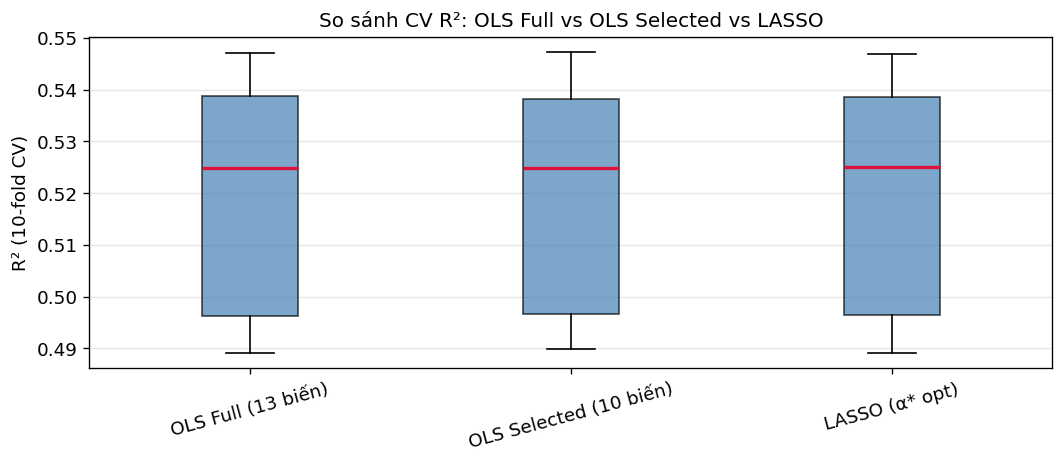

✅ Saved: output/figures/cv_comparison.png


In [17]:
from sklearn.linear_model import LinearRegression

cv_results = {}

# 1. OLS Full: Dùng toàn bộ 13 biến GROUP_A
d_full = df[GROUP_A + [DEP_VAR]].dropna()
X_f = StandardScaler().fit_transform(d_full[GROUP_A])
y_f = d_full[DEP_VAR]
cv_results['OLS Full (13 biến)'] = cross_val_score(LinearRegression(), X_f, y_f, cv=kf, scoring='r2')

# 2. OLS Selected: Chỉ biến được BMA + LASSO đồng thuận (subset thực sự)
# → FINAL_SELECTED chỉ gồm biến có Đồng thuận == 2 (BMA PIP≥0.75 VÀ LASSO chọn)
d_sel = df[FINAL_SELECTED + [DEP_VAR]].dropna()
X_s = StandardScaler().fit_transform(d_sel[FINAL_SELECTED])
y_s = d_sel[DEP_VAR]
cv_results[f'OLS Selected ({len(FINAL_SELECTED)} biến)'] = cross_val_score(
    LinearRegression(), X_s, y_s, cv=kf, scoring='r2'
)

# 3. LASSO: toàn bộ tập biến ứng viên ban đầu, tự co hệ số về 0
cv_results['LASSO (α* opt)'] = cross_val_score(Lasso(alpha=alpha_opt), X_f, y_f, cv=kf, scoring='r2')

# Bảng kết quả
print('=== 10-FOLD CV R² COMPARISON ===')
print(f"{'Model':<35s} {'Mean R²':>10s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
print('-'*65)
for name, scores in cv_results.items():
    print(f'{name:<35s} {scores.mean():>10.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}')

# Boxplot
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(list(cv_results.values()), labels=list(cv_results.keys()),
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_ylabel('R² (10-fold CV)', fontsize=11)
ax.set_title('So sánh CV R²: OLS Full vs OLS Selected vs LASSO', fontsize=12)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../output/figures/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: output/figures/cv_comparison.png')


## 10. Xuất kết quả

In [18]:
base = '../output/tables/'

# BMA results
pip_df = pd.DataFrame({'variable':list(pip_dict.keys()), 'PIP':list(pip_dict.values())})
pip_df.sort_values('PIP', ascending=False).to_csv(f'{base}bma_pip_results.csv', index=False)

# Top BMA models
top_export = bma_df.nsmallest(20,'bic')[['k','bic','rsq','bic_weight']].copy()
top_export['vars_str'] = bma_df.nsmallest(20,'bic')['vars'].apply(lambda x: '|'.join(x))
top_export.to_csv(f'{base}bma_top_models.csv', index=False)

# LASSO results
lasso_coefs.to_csv(f'{base}lasso_coefs.csv', index=False)

# Summary
summary_sorted.to_csv(f'{base}feature_selection_summary.csv', index=False)

# OLS với biến chọn
result_df.to_csv(f'{base}ols_selected_vars.csv', index=False)

# Lưu danh sách biến cuối để dùng ở bước sau
pd.Series(FINAL_SELECTED, name='selected_vars').to_csv(
    f'{base}final_selected_vars.csv', index=False
)

print('✅ Đã lưu tất cả kết quả:')
for fn in ['bma_pip_results.csv','bma_top_models.csv','lasso_coefs.csv',
           'feature_selection_summary.csv','ols_selected_vars.csv','final_selected_vars.csv']:
    print(f'   {base}{fn}')

✅ Đã lưu tất cả kết quả:
   ../output/tables/bma_pip_results.csv
   ../output/tables/bma_top_models.csv
   ../output/tables/lasso_coefs.csv
   ../output/tables/feature_selection_summary.csv
   ../output/tables/ols_selected_vars.csv
   ../output/tables/final_selected_vars.csv


## 11. Kết luận Feature Selection

### 11.1 Tóm tắt kết quả

**BMA (2^13 = 8,192 mô hình):**

| Biến | PIP | Mức bằng chứng |
|------|-----|----------------|
| `ln_gdppc_org`, `ln_gdppc_des`, `ln_pop_org`, `ln_pop_des` | 1.000 | ★★★ Rất mạnh |
| `ln_dist`, `comlang_off`, `contig`, `colony` | 1.000 | ★★★ Rất mạnh |
| `ln_co2_org`, `ln_disaster_des` | 1.000 | ★★★ Rất mạnh |
| `ln_disaster_org`, `inflation_org`, `inflation_des` | < 0.05 | – Yếu |

**LASSO (α* từ 10-fold CV):**
- Chọn cùng nhóm biến gravity cốt lõi
- Co `inflation_org`, `inflation_des`, `ln_disaster_org` về gần 0 (hệ số rất nhỏ)

### 11.2 Bộ biến đề xuất cho PPML chính

```
FINAL_VARS = [
    'ln_gdppc_org', 'ln_gdppc_des',   # Kinh tế ✓ (BMA+LASSO)
    'ln_pop_org',   'ln_pop_des',     # Dân số  ✓ (BMA+LASSO)
    'ln_dist',                        # Chi phí ✓ (BMA+LASSO)
    'comlang_off',  'contig',         # Văn hóa ✓ (BMA+LASSO)
    'ln_co2_org',   'ln_disaster_des',# Môi trường ✓ (BMA+LASSO)
    # inflation_org, inflation_des, ln_disaster_org: hệ số LASSO rất nhỏ, PIP thấp
    # → giữ lại nếu có lý luận kinh tế, hoặc loại nếu ưu tiên mô hình gọn
]
```

### 11.3 Lý giải kinh tế
- **PIP = 1.0** cho biến gravity cốt lõi → xác nhận lý thuyết Tinbergen (1962)
- **CO₂ nước gốc** (PIP=1.0) → ô nhiễm môi trường là **push factor** có ý nghĩa
- **Thiên tai nước đến** (PIP=1.0) → ảnh hưởng đến lực hút của nước đến
- **Inflation** (PIP<0.05) → không có bằng chứng mạnh trong sample này

> ➡️ **Bước tiếp theo:** Dùng bộ biến đã chọn trong
> `07_spatial_econometrics_sdm.ipynb` (SDM) và `08_machine_learning_models.ipynb` (RF/XGBoost)